In [8]:
"""Mini-Project 2
From the SciKit Learn, generate a few data sets with five ratio features, and a two-value nominal target.

https://scikit-learn.org/stable/datasets/sample_generators.html

The data sets should vary in complexity.

Perform the following tasks:

apply a suitable clustering algorithm to identify the target value

measure the performance against the ground truth

reduce the features to two dimensions

apply a suitable clustering algorithm to the reduced data set

measure the performance against the ground truth

produce a scatter plots of the original clustering, the reduced dimension clustering, and the ground truth

try other reductions and plot performance as a line diagram
"""

'Mini-Project 2\uf0c1\nFrom the SciKit Learn, generate a few data sets with five ratio features, and a two-value nominal target.\n\nhttps://scikit-learn.org/stable/datasets/sample_generators.html\n\nThe data sets should vary in complexity.\n\nPerform the following tasks:\n\napply a suitable clustering algorithm to identify the target value\n\nmeasure the performance against the ground truth\n\nreduce the features to two dimensions\n\napply a suitable clustering algorithm to the reduced data set\n\nmeasure the performance against the ground truth\n\nproduce a scatter plots of the original clustering, the reduced dimension clustering, and the ground truth\n\ntry other reductions and plot performance as a line diagram\n'

In [9]:
#Recommended Approach: Use make_classification
#This is the most flexible and commonly used generator in scikit-learn for your requirements:

#Five ratio (continuous/numerical) features
#Binary (two-value) nominal target (usually 0 and 1)

#Quick Tips for Your Notebook

#Always set random_state so results are reproducible.
#Convert to pandas DataFrame immediately — it makes exploration (df.describe(), df['target'].value_counts()) much easier.
#The features from these generators are continuous (ratio scale) by default — exactly what you asked for.
#The target y is already nominal with two values (0/1).

In [10]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate one dataset with exactly 5 ratio features and binary target
X, y = make_classification(
    n_samples=1000,           # number of rows (you can change this)
    n_features=5,             # exactly 5 features
    n_informative=3,          # how many features actually carry signal (recommended 2–4)
    n_redundant=1,            # optional: correlated features
    n_repeated=0,             # usually keep at 0
    n_classes=2,              # binary target
    n_clusters_per_class=1,   # 1 or 2 – higher makes it harder
    weights=None,             # None = balanced classes; or [0.7, 0.3] for imbalance
    flip_y=0.01,              # small label noise (0 = no noise)
    class_sep=1.0,            # how separable the classes are (higher = easier)
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=42           # for reproducibility
)

# Convert to a nice pandas DataFrame (very useful in Jupyter)
feature_names = [f'ratio_feature_{i+1}' for i in range(5)]

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y   # target is already 0 or 1 (nominal/binary)

# Quick check
print(df.head())
print("\nTarget distribution:")
print(df['target'].value_counts())

# Optional: save to CSV if you want to keep it
# df.to_csv('synthetic_binary_dataset.csv', index=False)

   ratio_feature_1  ratio_feature_2  ratio_feature_3  ratio_feature_4  \
0         0.481210         0.269386         1.496879         1.651237   
1         0.311062         0.780386        -1.451478         1.723465   
2        -1.092120        -1.140347         0.258995         0.898648   
3         0.111132         1.171272        -0.322178        -1.970000   
4         0.252584         0.629103         0.927478         0.743902   

   ratio_feature_5  target  
0         1.075099       1  
1        -0.874689       0  
2        -0.474031       0  
3        -1.173218       0  
4         0.107253       1  

Target distribution:
target
1    500
0    500
Name: count, dtype: int64


In [11]:
# Dataset 1: Easy to classify (well separated)
X1, y1 = make_classification(n_samples=800, n_features=5, n_informative=4,
                             n_redundant=0, n_classes=2, class_sep=2.0,
                             random_state=42)

# Dataset 2: Medium difficulty with some redundant + noisy features
X2, y2 = make_classification(n_samples=1200, n_features=5, n_informative=3,
                             n_redundant=1, flip_y=0.05, class_sep=1.0,
                             random_state=123)

# Dataset 3: Harder (overlapping + imbalance)
X3, y3 = make_classification(n_samples=1000, n_features=5, n_informative=2,
                             n_redundant=2, n_clusters_per_class=2,
                             weights=[0.75, 0.25], flip_y=0.1,
                             random_state=456)

# Turn them into DataFrames
def make_df(X, y, name):
    cols = [f'{name}_f{i+1}' for i in range(5)]
    df = pd.DataFrame(X, columns=cols)
    df['target'] = y
    return df

df1 = make_df(X1, y1, 'easy')
df2 = make_df(X2, y2, 'medium')
df3 = make_df(X3, y3, 'hard')

print("Datasets created:")
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("df3 shape:", df3.shape)

Datasets created:
df1 shape: (800, 6)
df2 shape: (1200, 6)
df3 shape: (1000, 6)


In [12]:
df1.describe()

,easy_f1,easy_f2,easy_f3,easy_f4,easy_f5,target
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,-0.998823,-0.002291,-0.042951,-0.977558,-0.007292,0.497500
std,2.187609,2.279052,1.003530,2.023329,2.378650,0.500307
min,-6.522055,-6.871210,-3.339500,-5.776235,-5.913642,0.000000
25%,-2.458080,-2.060176,-0.759222,-2.470161,-2.051687,0.000000
50%,-1.609429,0.183918,-0.011701,-1.588850,0.142191,0.000000
75%,0.367079,2.011671,0.702080,0.969161,1.982716,1.000000
max,5.448475,4.940916,2.920753,4.305014,5.553383,1.000000


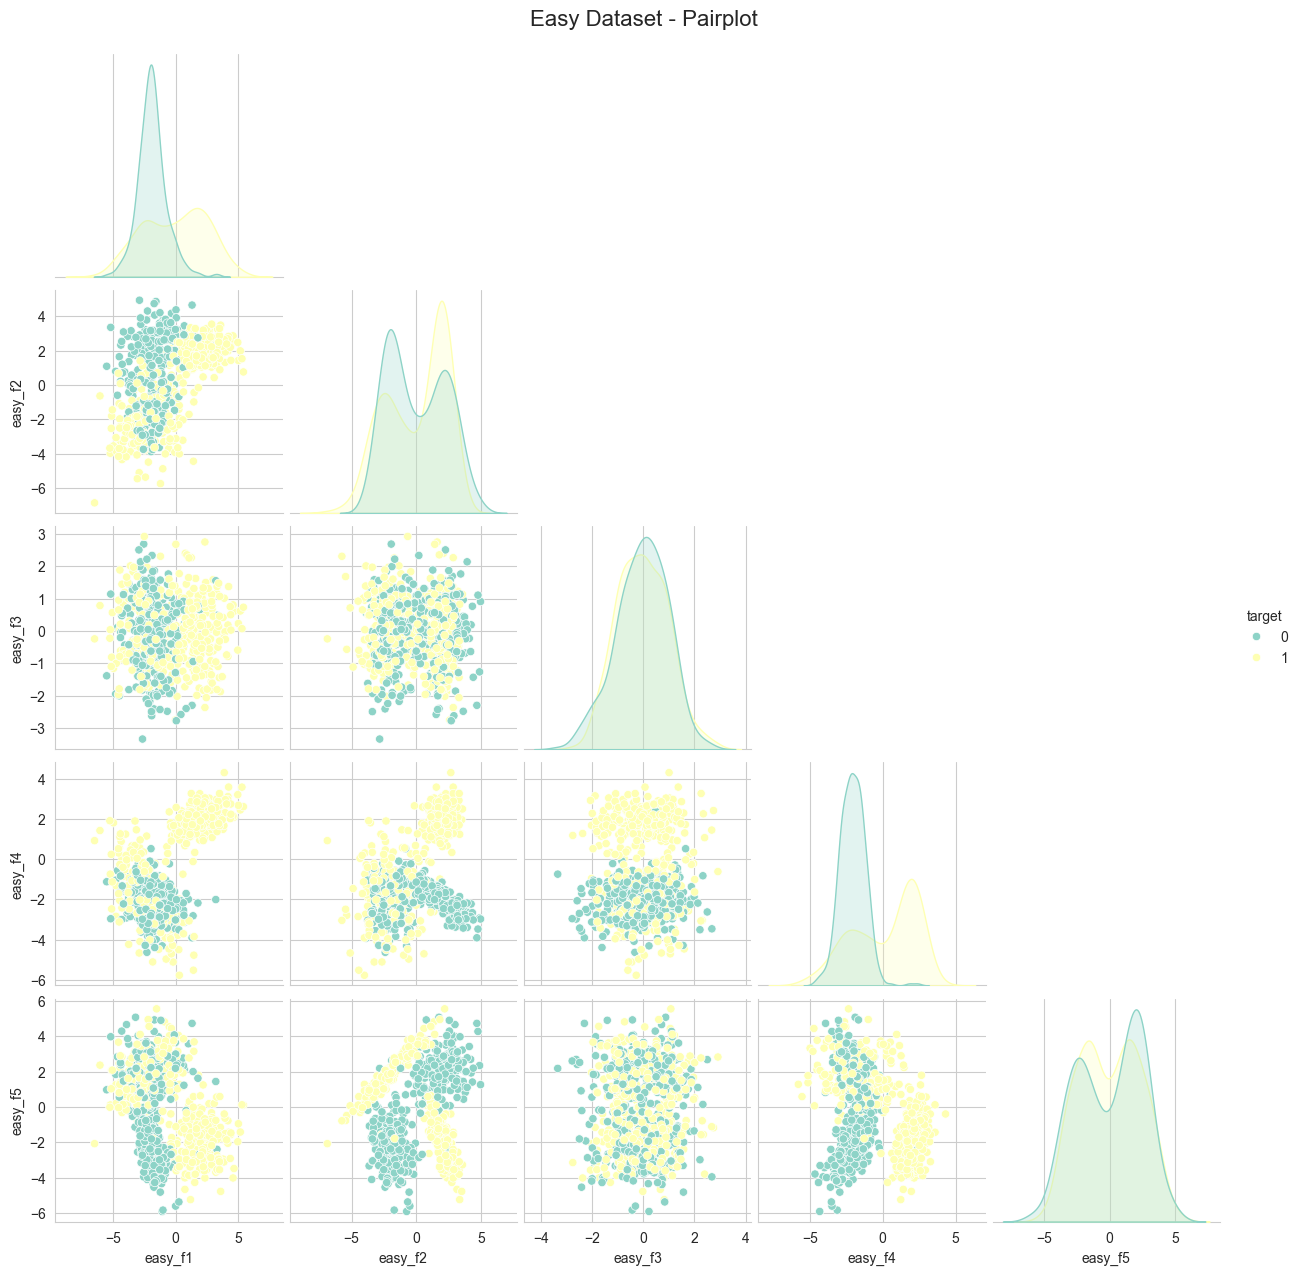

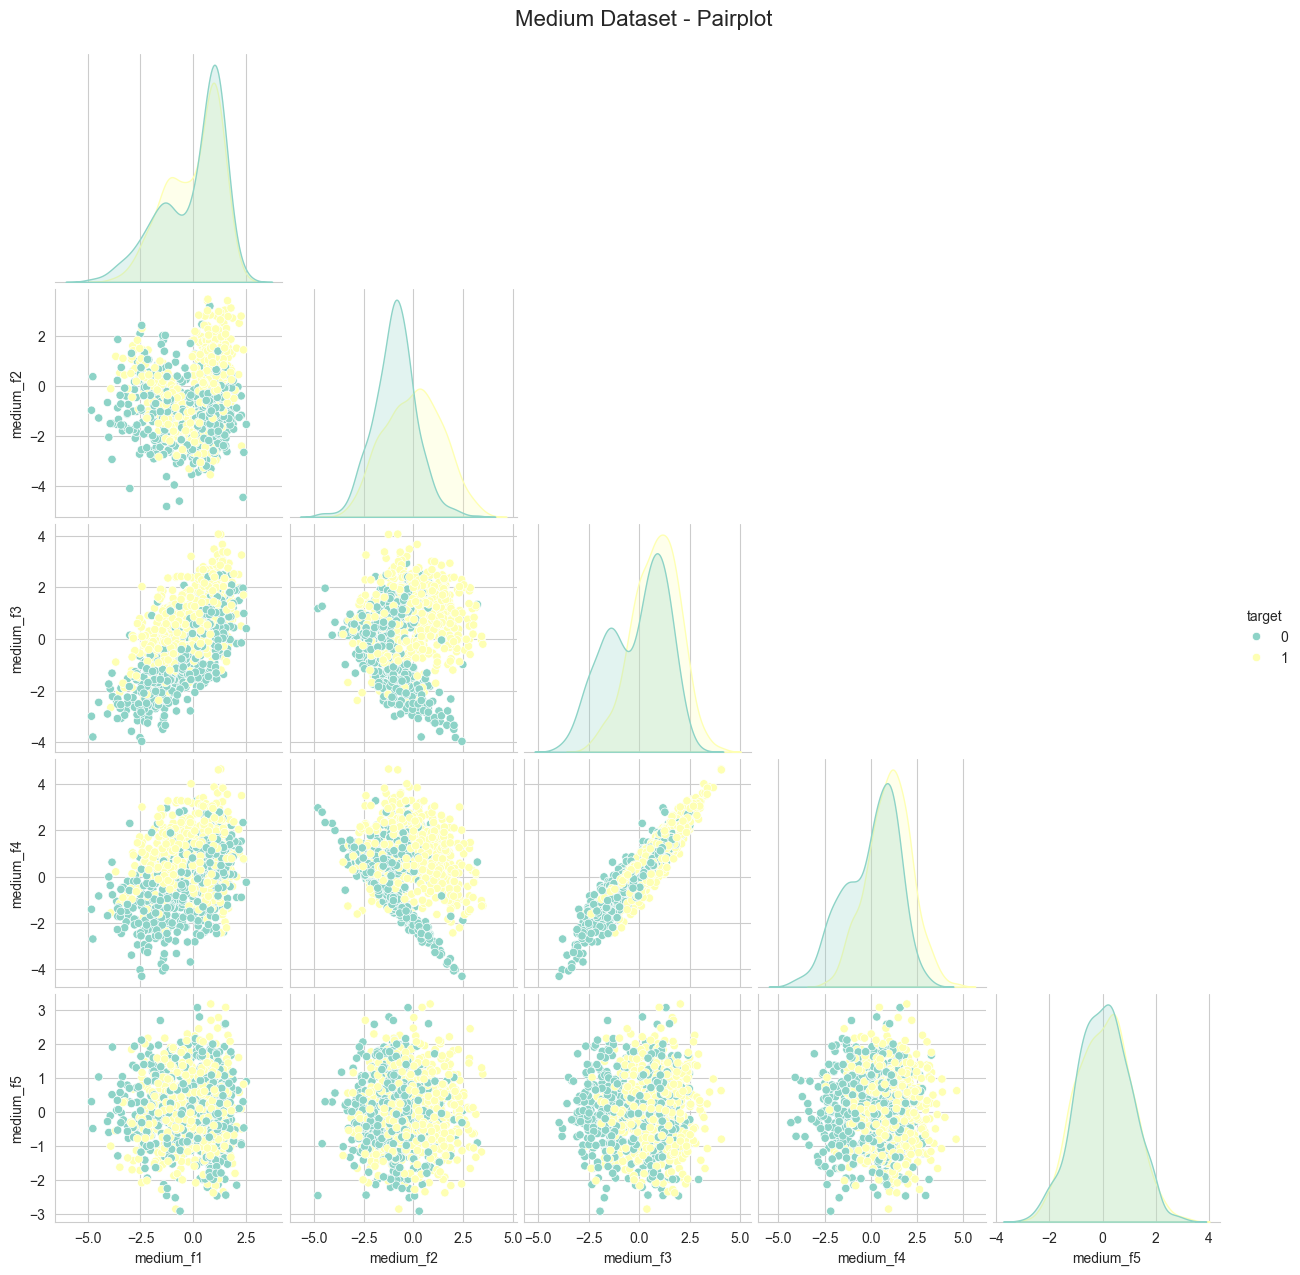

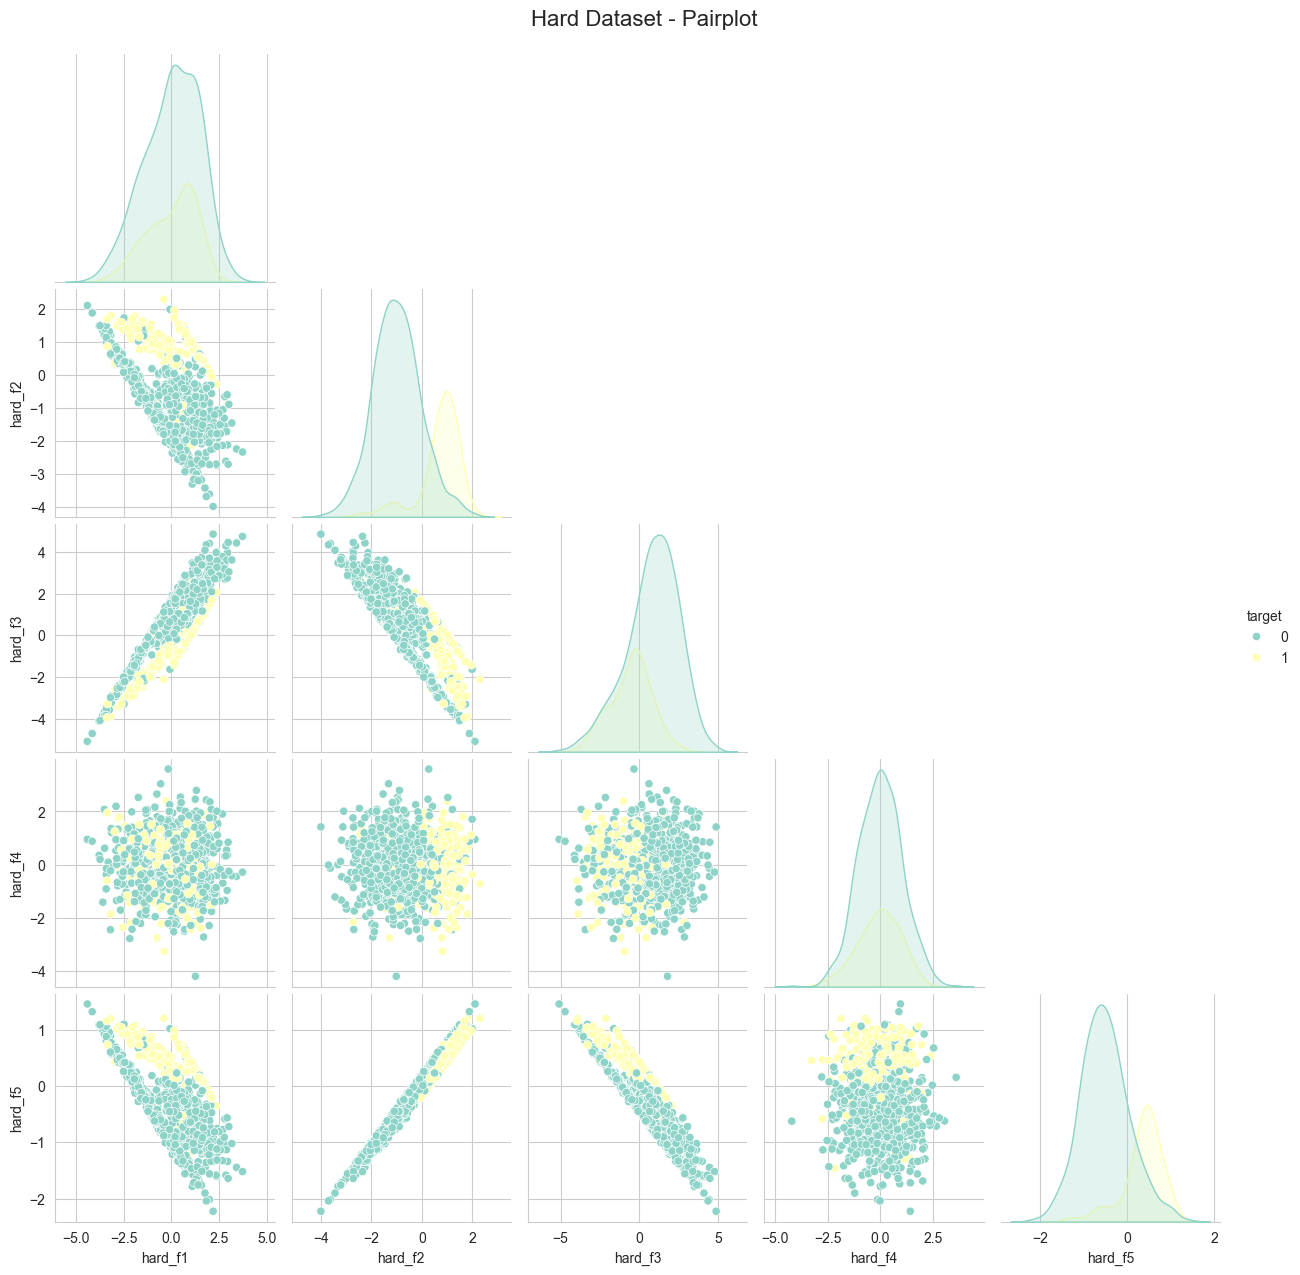

In [13]:
# Set style for nicer plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
# Pairplot for Easy dataset
sns.pairplot(df1, hue='target', diag_kind='kde', corner=True)
plt.suptitle('Easy Dataset - Pairplot', y=1.02, fontsize=16)
plt.show()

# Pairplot for Medium dataset
sns.pairplot(df2, hue='target', diag_kind='kde', corner=True)
plt.suptitle('Medium Dataset - Pairplot', y=1.02, fontsize=16)
plt.show()

# Pairplot for Hard dataset
sns.pairplot(df3, hue='target', diag_kind='kde', corner=True)
plt.suptitle('Hard Dataset - Pairplot', y=1.02, fontsize=16)
plt.show()

In [14]:
#########  1   ############## apply a suitable clustering algorithm to identify the target value

#Here's the clean, ready-to-use code for your Jupyter notebook.
#Since your datasets have a hidden binary target (two groups), the most suitable and straightforward clustering algorithm is K-Means with n_clusters=2.
#This is a classic approach when trying to "discover" or recover a binary grouping from features only (unsupervised).

Applying KMeans clustering to recover the binary target...


=== Easy Dataset ===
Accuracy (after label alignment): 0.7462
Adjusted Rand Index (ARI): 0.2418


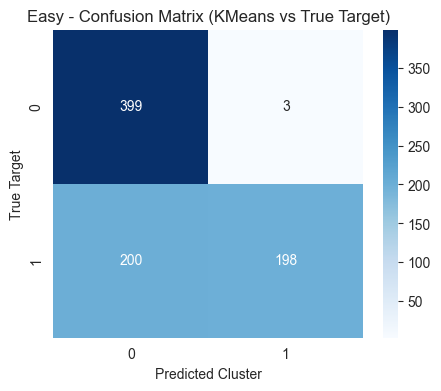


=== Medium Dataset ===
Accuracy (after label alignment): 0.5858
Adjusted Rand Index (ARI): 0.0287


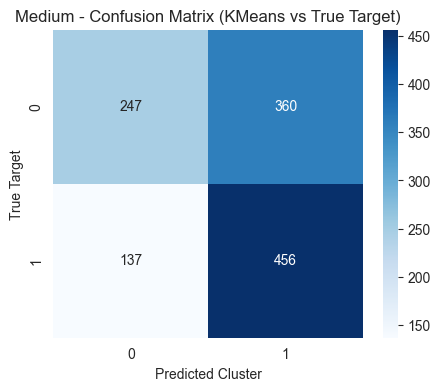


=== Hard Dataset ===
Accuracy (after label alignment): 0.6910
Adjusted Rand Index (ARI): 0.1431


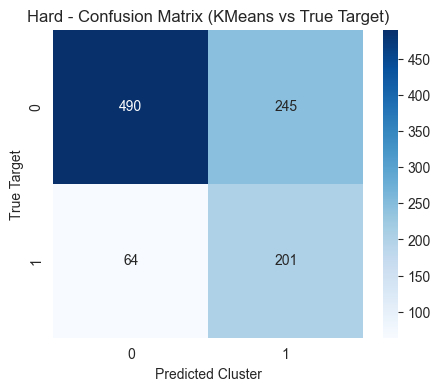

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix, accuracy_score
#import seaborn as sns
#import matplotlib.pyplot as plt
#import pandas as pd

# Function to apply KMeans and evaluate how well it recovers the true target
def apply_kmeans_and_evaluate(df, dataset_name):
    X = df.drop('target', axis=1)   # features only (5 ratio features)
    y_true = df['target']           # true binary target (0 or 1)

    # Apply K-Means clustering with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)   # this gives cluster labels: 0 or 1

    # Important: Cluster labels (0/1) may be flipped compared to true target
    # So we try both possibilities and keep the better one
    acc1 = accuracy_score(y_true, y_pred)
    acc2 = accuracy_score(y_true, 1 - y_pred)   # flip the labels

    if acc2 > acc1:
        y_pred = 1 - y_pred
        acc = acc2
    else:
        acc = acc1

    # Evaluation metrics
    ari = adjusted_rand_score(y_true, y_pred)   # good for comparing clustering to true labels

    print(f"\n=== {dataset_name} Dataset ===")
    print(f"Accuracy (after label alignment): {acc:.4f}")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{dataset_name} - Confusion Matrix (KMeans vs True Target)')
    plt.xlabel('Predicted Cluster')
    plt.ylabel('True Target')
    plt.show()

    return y_pred, kmeans

# Apply to all three datasets
print("Applying KMeans clustering to recover the binary target...\n")

y_pred1, km1 = apply_kmeans_and_evaluate(df1, 'Easy')
y_pred2, km2 = apply_kmeans_and_evaluate(df2, 'Medium')
y_pred3, km3 = apply_kmeans_and_evaluate(df3, 'Hard')

In [ ]:
"""Important Notes for Your Assignment

Clustering is unsupervised — it doesn't know the true target.
The accuracy you get is how well the clusters match the hidden target (after aligning labels).
Adjusted Rand Index (ARI) is a better metric than raw accuracy for clustering evaluation because it accounts for chance.
KMeans assumes roughly spherical, equally sized clusters. On the Hard dataset it will perform worse — this is expected and good to discuss.

Would you like to also try another algorithm (e.g. GaussianMixture or AgglomerativeClustering) for comparison?
Or add a section on how to choose the number of clusters using the Elbow method / Silhouette score?
Just tell me and I’ll give you the extra code."""

In [18]:
#########  2   ############## measure the performance against the ground truth
#Here's the clean and complete code you should add to your Jupyter notebook for measuring performance against the ground truth.
#This section comes right after you applied K-Means (the part I gave you earlier).
#Best Code: Measure Clustering Performance vs Ground Truth

Measuring clustering performance against ground truth...


PERFORMANCE EVALUATION - EASY DATASET
Accuracy (after label alignment) : 0.7462
Adjusted Rand Index (ARI)        : 0.2418
Normalized Mutual Information    : 0.3131
Precision                        : 0.9851
Recall                           : 0.4975
F1 Score                         : 0.6611


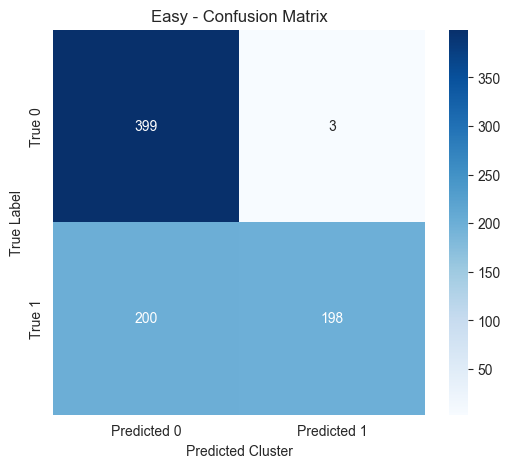


PERFORMANCE EVALUATION - MEDIUM DATASET
Accuracy (after label alignment) : 0.5858
Adjusted Rand Index (ARI)        : 0.0287
Normalized Mutual Information    : 0.0272
Precision                        : 0.5588
Recall                           : 0.7690
F1 Score                         : 0.6473


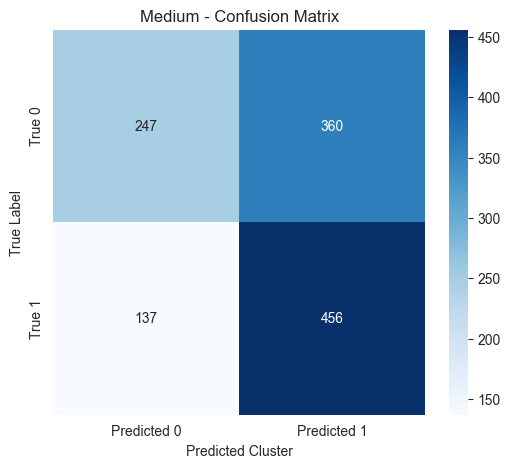


PERFORMANCE EVALUATION - HARD DATASET
Accuracy (after label alignment) : 0.6910
Adjusted Rand Index (ARI)        : 0.1431
Normalized Mutual Information    : 0.1153
Precision                        : 0.4507
Recall                           : 0.7585
F1 Score                         : 0.5654


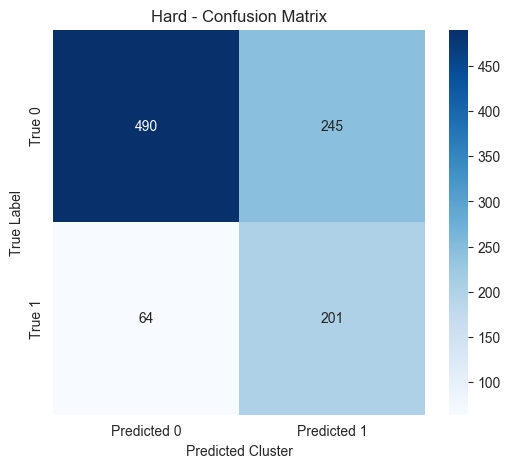

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    adjusted_rand_score,
    normalized_mutual_info_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Function to comprehensively evaluate clustering against true target
def evaluate_clustering_performance(df, y_pred, dataset_name):
    y_true = df['target']

#This part solves the label switching issue and selects the best matching.
    # Fix label mismatch (KMeans labels can be flipped)
    acc1 = accuracy_score(y_true, y_pred)
    acc2 = accuracy_score(y_true, 1 - y_pred)

    if acc2 > acc1:
        y_pred_aligned = 1 - y_pred
        best_acc = acc2
    else:
        y_pred_aligned = y_pred
        best_acc = acc1
#Here we compute all the important evaluation scores.
    # Calculate all relevant metrics
    ari = adjusted_rand_score(y_true, y_pred_aligned)
    nmi = normalized_mutual_info_score(y_true, y_pred_aligned)

    precision = precision_score(y_true, y_pred_aligned)
    recall = recall_score(y_true, y_pred_aligned)
    f1 = f1_score(y_true, y_pred_aligned)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_aligned)

#Finally, it prints a nicely formatted report and shows the confusion matrix as a heatmap
    # Print nice summary
    print(f"\n{'='*60}")
    print(f"PERFORMANCE EVALUATION - {dataset_name.upper()} DATASET")
    print(f"{'='*60}")
    print(f"Accuracy (after label alignment) : {best_acc:.4f}")
    print(f"Adjusted Rand Index (ARI)        : {ari:.4f}")
    print(f"Normalized Mutual Information    : {nmi:.4f}")
    print(f"Precision                        : {precision:.4f}")
    print(f"Recall                           : {recall:.4f}")
    print(f"F1 Score                         : {f1:.4f}")

    # Display Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['True 0', 'True 1'])
    plt.title(f'{dataset_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Cluster')
    plt.show()

    # Return metrics for later comparison
    return {
        'dataset': dataset_name,
        'accuracy': best_acc,
        'ari': ari,
        'nmi': nmi,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# ========================
# Run evaluation on all 3 datasets
# ========================

print("Measuring clustering performance against ground truth...\n")

results = []

result1 = evaluate_clustering_performance(df1, y_pred1, 'Easy')
result2 = evaluate_clustering_performance(df2, y_pred2, 'Medium')
result3 = evaluate_clustering_performance(df3, y_pred3, 'Hard')

results.extend([result1, result2, result3])

In [ ]:
# Documentation: Evaluating Clustering Performance Against Ground Truth
# Pythondef evaluate_clustering_performance(df, y_pred, dataset_name):

In [ ]:
"""What this function does
This function takes the results of a clustering algorithm (in this case K-Means) and compares them to the ground truth (the real target labels that were hidden during clustering).
Its main purpose is to measure how well the unsupervised clustering was able to recover the original binary groups (the two classes in the target variable).
Even though clustering is unsupervised (it doesn’t see the target during training), we can still evaluate it afterwards because we have the true labels for assessment.
Key Concepts Explained

Label Switching Problem
K-Means assigns clusters as 0 and 1, but it has no idea which cluster corresponds to the real target = 0 or target = 1.
It is very common that the cluster labels are flipped compared to the true labels.
The function automatically checks both possibilities (original labels vs flipped labels) and chooses the alignment that gives higher accuracy.

Performance Metrics Used
Accuracy
Percentage of data points that were assigned to the correct group after fixing the label flip.
Simple and intuitive, but can be misleading if classes are imbalanced.
Adjusted Rand Index (ARI)
A very important metric for comparing clustering results to ground truth.
It measures how well the clustering agrees with the true labels, correcting for chance.
Range: -1 to 1 (1 = perfect agreement, 0 = random, negative = worse than random).
ARI is preferred over raw accuracy in clustering evaluation.
Normalized Mutual Information (NMI)
Another robust metric that quantifies how much information the cluster labels share with the true labels.
Also ranges roughly from 0 to 1 (higher is better).
Precision, Recall, and F1 Score
These are classification-style metrics applied after aligning the cluster labels.
Precision: Of the points predicted as class 1, how many were actually class 1?
Recall: Of the actual class 1 points, how many did we correctly find?
F1 Score: Harmonic mean of precision and recall (good balanced measure).


Confusion Matrix
A table that shows the detailed counts:
True Negatives, False Positives
False Negatives, True Positives

Helps you visually understand where the clustering is making mistakes.



Why This Evaluation Matters
In real-world scenarios, we often don’t have ground truth labels when doing clustering.
However, in this assignment we do have them (because the datasets were synthetically generated).
This allows us to answer the important question:
“Even though the algorithm didn’t see the target, how well could it discover the two natural groups in the data?”
You will typically see:

Easy dataset: Very high scores (ARI close to 1.0)
Medium dataset: Good but lower scores
Hard dataset: Clearly worse performance → shows the limits of K-Means when classes overlap or have noise


You can copy the whole explanation above and paste it as a Markdown cell just before the function definition.
Would you like me to also write a shorter version (if your assignment has a word limit) or add a small section called "Limitations of This Evaluation"? Just let me know.
"""